In [15]:
import pandas as pd
import seaborn as sns
sns.set()
import mlflow
import subprocess
import matplotlib.pyplot as plt

from pathlib import Path

from qrt.data import load_tr_data
from qrt.splitters import make_date_folds
from qrt.train import train_and_predict_cv, predict_positive_probability
from qrt.features import compute_features

from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

In [16]:
X_tr, y_tr = load_tr_data(Path("../data/raw"))

In [17]:
mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("qrt-aapf")

cv_params = {"n_splits": 8, "seed": 42}
folds = make_date_folds(X_tr, **cv_params)

X = compute_features(X_tr)
# Remove date identifiers and the six context features
X = X.drop(columns=["TS"])
X = X.drop(columns=X.filter(regex="^TS_").columns)

# Declare allocation and group identifiers as categorical features
for col in ["GROUP", "ALLOCATION"]:
    X[col] = X[col].astype("category")

    
y = (y_tr["target"] > 0).astype(int)

model = LGBMClassifier(
    n_estimators=200,
    num_leaves=7,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1,
    cat_smooth=1000,
)


In [18]:
root = Path("..").resolve()

with mlflow.start_run(run_name="lgbm_fts_v2_categories_cat_smooth_1000") as run:
    # Record the experiment configuration
    mlflow.set_tags({
        "model": type(model).__name__,
        "reason": "Test stronger categorical regularization",
        "git_commit": subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=root, text=True
        ).strip(),
    })

    mlflow.log_params(model.get_params())
    mlflow.log_params({
        "cv_n_splits": cv_params["n_splits"],
        "cv_seed": cv_params["seed"],
        "prediction_threshold": 0.5,
    })

    mlflow.log_dict({
        "features": X.columns.tolist(),
        "n_features": X.shape[1],
        "target": "target > 0",
        "training_files": ["X_train.csv", "y_train.csv"],
        "cv_method": "KFold on shuffled unique TS",
    }, "config.json")

    # Save the source files, including uncommitted changes
    for path in (root / "src/qrt").glob("*.py"):
        mlflow.log_artifact(str(path), artifact_path="source/qrt")

    for name in (
        "pyproject.toml",
        "uv.lock",
        "notebooks/02_models.ipynb",
    ):
        mlflow.log_artifact(str(root / name), artifact_path="source")

    # Train and evaluate
    oof, models = train_and_predict_cv(
        model, X, y, folds, predict_positive_probability,
        return_models=True,
    )
    assert oof.notna().all()

    y_pred = (oof >= 0.5).astype(int)
    scores = {"accuracy": accuracy_score(y, y_pred)}
    for fold in sorted(folds.unique()):
        rows = folds == fold
        scores[f"accuracy_fold_{fold}"] = accuracy_score(y[rows], y_pred[rows])

    mlflow.log_metrics(scores)

    # Save predictions and the exact fold assignments
    predictions = pd.DataFrame({
        "fold": folds,
        "target": y,
        "prediction": oof,
    })
    mlflow.log_text(predictions.to_csv(), "oof.csv")

pd.Series(scores)

🏃 View run lgbm_fts_v2_categories_cat_smooth_1000 at: http://127.0.0.1:5001/#/experiments/2/runs/f450faaa6dd044eeaa20482551cf260c
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


accuracy           0.524203
accuracy_fold_0    0.525756
accuracy_fold_1    0.525391
accuracy_fold_2    0.521221
accuracy_fold_3    0.525954
accuracy_fold_4    0.515864
accuracy_fold_5    0.524418
accuracy_fold_6    0.525376
accuracy_fold_7    0.530326
dtype: float64

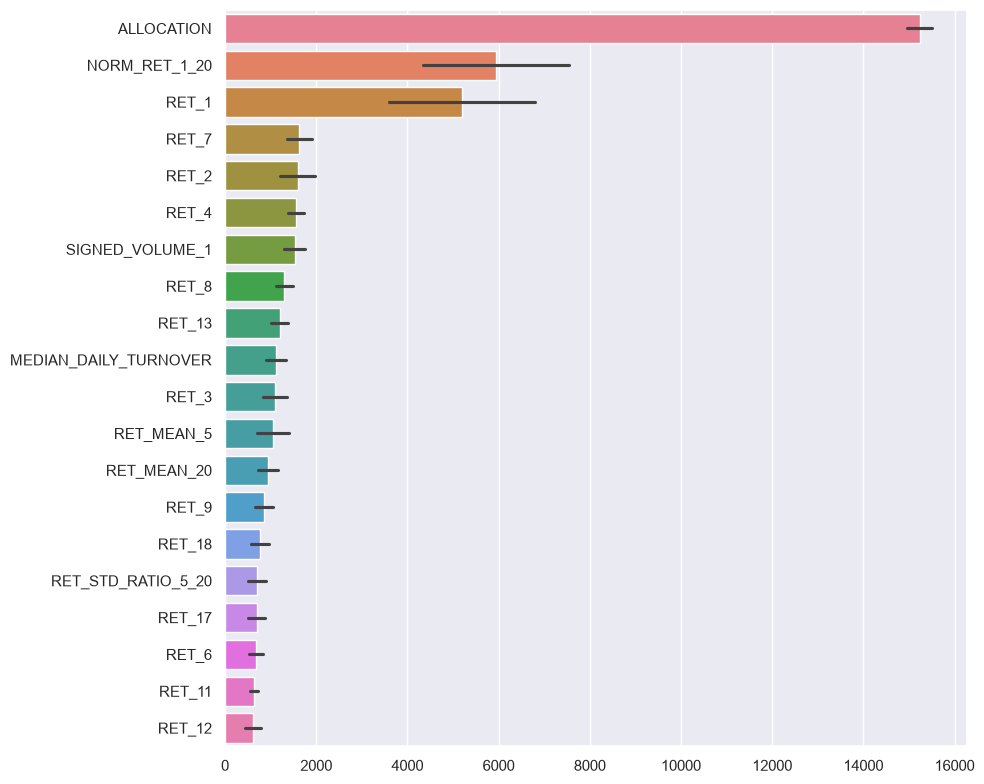

In [19]:
feature_importances = pd.DataFrame(
    [
        m.booster_.feature_importance(importance_type="gain")
        for m in models
    ],
    columns=X.columns,
)
top_features = feature_importances.mean().nlargest(20).index

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importances[top_features],
    orient="h",
    order=top_features,
    errorbar="sd",
)
plt.tight_layout()
plt.show()

In [20]:
new_features = X.columns.difference(X_tr.columns)

feature_importances[new_features].agg(["mean", "std"]).T.sort_values(
    "mean", ascending=False
)

,mean,std
NORM_RET_1_20,5940.843814,1598.906593
RET_MEAN_5,1051.024189,342.412401
RET_MEAN_20,946.227573,218.034934
RET_STD_RATIO_5_20,704.958095,194.588178
RET_WIN_RATE_20,322.037220,132.795515
RET_STD_5,291.917514,151.239336
SIGNED_VOLUME_STD_5,181.125327,31.662686
RET_STD_20,115.101862,64.056135
SIGNED_VOLUME_MEAN_5,105.443805,52.363445
SIGNED_VOLUME_STD_20,104.635675,77.125137


In [21]:
diagnostics = []

for fold, fold_model in zip(sorted(folds.unique()), models):
    train_rows = folds != fold
    validation_rows = folds == fold

    train_pred = (
        predict_positive_probability(fold_model, X.loc[train_rows]) >= 0.5
    )

    diagnostics.append({
        "fold": fold,
        "train": accuracy_score(y.loc[train_rows], train_pred),
        "validation": accuracy_score(
            y.loc[validation_rows], y_pred.loc[validation_rows]
        ),
    })

pd.DataFrame(diagnostics).set_index("fold") * 100

,train,validation
fold,,
0,54.101507,52.575618
1,54.079729,52.539132
2,54.154005,52.122051
3,54.135143,52.595363
4,54.257990,51.586393
5,54.079278,52.441780
6,54.104752,52.537640
7,54.048942,53.032612
